# Harmonic Coordinates and Mesh Parameterisation

**Harmonic coordinates** generalise barycentric coordinates to arbitrary (non-convex) polygons. Given a closed polygon $\Omega$ with boundary vertices $p_1, \ldots, p_k$, the harmonic coordinate $\lambda_i(x)$ for vertex $p_i$ satisfies:
$$
\Delta \lambda_i = 0 \quad \text{in } \Omega, \qquad \lambda_i(p_j) = \delta_{ij} \quad \text{on } \partial\Omega.
$$
They form a **partition of unity**: $\sum_i \lambda_i(x) = 1$ for all $x \in \Omega$.

## Mesh parameterisation

Given a 2D mesh with boundary vertices fixed to a target shape (e.g., a unit circle or square), harmonic coordinates give the optimal interior layout by minimising the **Dirichlet energy**:
$$
E(u) = \int_\Omega \|\nabla u\|^2 = u^\top L u,
$$
where $L$ is a discrete graph Laplacian on the mesh (here: uniform weights). For convex boundary constraints, this harmonic map satisfies a discrete maximum principle and produces a fold-free embedding in this setting.

## Floater's mean-value coordinates

For non-convex boundaries, **mean-value coordinates** provide an efficient closed-form alternative that is positive everywhere.

## Applications

- **UV parameterisation** of 3D meshes for texture mapping.
- **Shape deformation**: fix some boundary/handle positions, solve for interior via Laplace.
- **Mesh morphing**: interpolate between two shapes via harmonic maps.

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from matplotlib.tri import Triangulation
from ipywidgets import interact, IntSlider, FloatSlider

plt.rcParams['figure.dpi'] = 120

## Building a 2D triangulated mesh

We triangulate a square domain and identify boundary and interior vertices.

In [2]:
def make_square_mesh(m):
    """Uniform triangulated mesh on [0,1]^2 with m+1 points per side."""
    x = np.linspace(0, 1, m+1)
    y = np.linspace(0, 1, m+1)
    X, Y = np.meshgrid(x, y)
    pts = np.column_stack([X.ravel(), Y.ravel()])
    # Triangles
    tris = []
    for i in range(m):
        for j in range(m):
            a = i*(m+1)+j; b = a+1; c = a+(m+1); d = c+1
            tris.append([a, b, d])
            tris.append([a, d, c])
    tris = np.array(tris)
    # Boundary mask
    bnd = (pts[:,0] == 0) | (pts[:,0] == 1) | (pts[:,1] == 0) | (pts[:,1] == 1)
    return pts, tris, bnd

m = 15
pts, tris, bnd = make_square_mesh(m)
N = len(pts)
n_int = (~bnd).sum()
print(f'Mesh: {N} vertices, {len(tris)} triangles, {n_int} interior vertices')

Mesh: 256 vertices, 450 triangles, 196 interior vertices


## Discrete Laplacian and harmonic parameterisation

We use the **uniform Laplacian** (equal weights) and solve the Dirichlet problem: fix boundary vertices to a circle, solve for interior vertices.

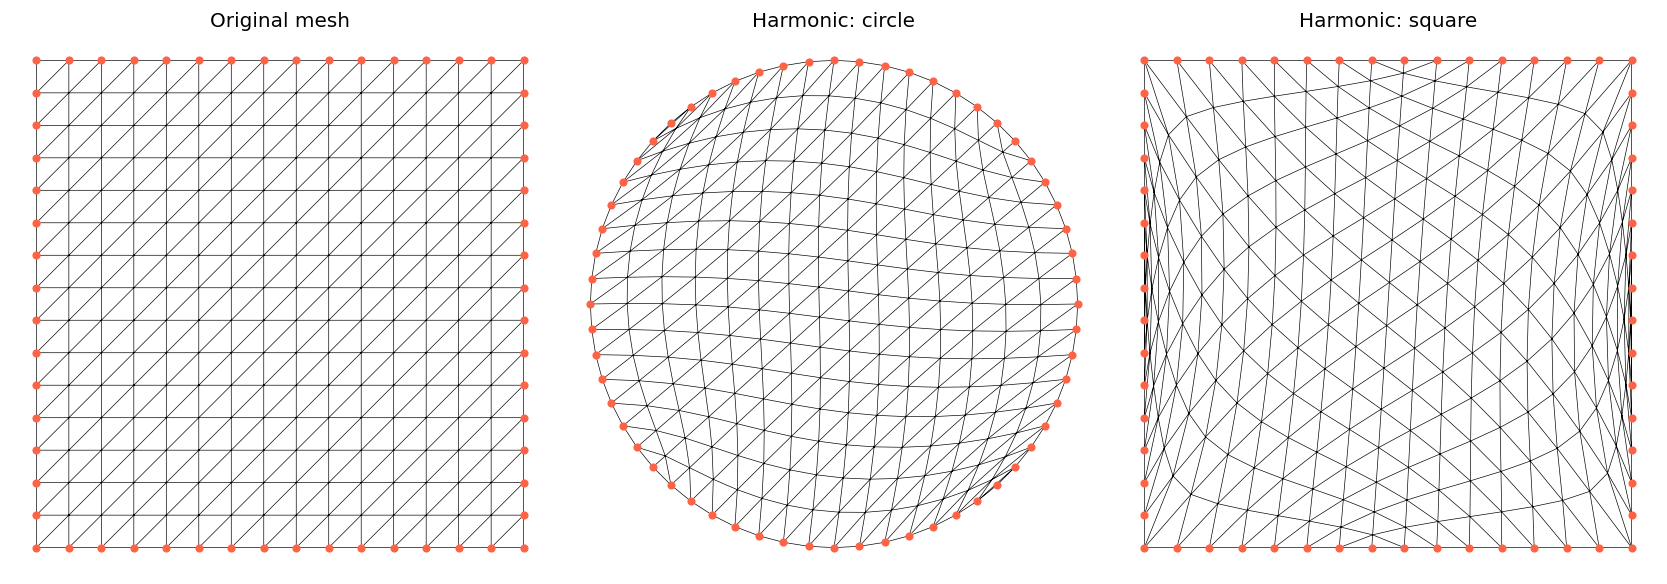

In [3]:
def build_uniform_laplacian(pts, tris, bnd):
    N = len(pts)
    adj = [set() for _ in range(N)]
    for t in tris:
        for i in range(3):
            for j in range(3):
                if i != j: adj[t[i]].add(t[j])
    rows, cols_sp, vals = [], [], []
    for i in range(N):
        if not bnd[i]:
            deg = len(adj[i])
            rows.append(i); cols_sp.append(i); vals.append(float(deg))
            for j in adj[i]:
                rows.append(i); cols_sp.append(j); vals.append(-1.0)
    L = sp.csr_matrix((vals, (rows, cols_sp)), shape=(N, N))
    return L

L = build_uniform_laplacian(pts, tris, bnd)

def harmonic_param(pts, L, bnd, target_pts):
    """Solve L*u = 0 for interior, u = target_pts on boundary."""
    N = len(pts)
    int_idx = np.where(~bnd)[0]
    bnd_idx = np.where(bnd)[0]
    # Build system: L_int * u_int = -L_bnd * u_bnd
    L_int = L[np.ix_(int_idx, int_idx)]
    L_bnd = L[np.ix_(int_idx, bnd_idx)]
    rhs = -L_bnd @ target_pts[bnd_idx]
    u_int = spla.spsolve(L_int, rhs)
    u_new = target_pts.copy()
    u_new[int_idx] = u_int
    return u_new

# Map boundary to unit circle
bnd_idx = np.where(bnd)[0]
bnd_pts = pts[bnd_idx]
# Sort boundary by angle
center = bnd_pts.mean(axis=0)
angles = np.arctan2(bnd_pts[:,1]-center[1], bnd_pts[:,0]-center[0])
order = np.argsort(angles)
bnd_sorted = bnd_idx[order]
circle_pts = np.column_stack([np.cos(np.linspace(0, 2*np.pi, len(bnd_idx), endpoint=False)),
                               np.sin(np.linspace(0, 2*np.pi, len(bnd_idx), endpoint=False))])
target = np.zeros((N, 2))
target[bnd_sorted] = circle_pts
u_circle = harmonic_param(pts, L, bnd, target)

# Also map to square
target_sq = np.zeros((N, 2))
# Map boundary to unit square perimeter
ntot = len(bnd_sorted)
for k, idx in enumerate(bnd_sorted):
    frac = k / ntot
    if frac < 0.25:   s = frac*4;   target_sq[idx] = [s, 0]
    elif frac < 0.5:  s=(frac-0.25)*4; target_sq[idx]=[1, s]
    elif frac < 0.75: s=(frac-0.5)*4;  target_sq[idx]=[1-s, 1]
    else:             s=(frac-0.75)*4; target_sq[idx]=[0, 1-s]
u_square = harmonic_param(pts, L, bnd, target_sq)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (u_pts, title) in zip(axes, [
    (pts, 'Original mesh'),
    (u_circle, 'Harmonic: circle'),
    (u_square, 'Harmonic: square'),
]):
    ax.triplot(u_pts[:,0], u_pts[:,1], tris, 'k-', lw=0.4)
    ax.scatter(u_pts[bnd,0], u_pts[bnd,1], s=15, c='tomato', zorder=5)
    ax.set_aspect('equal'); ax.axis('off'); ax.set_title(title)

plt.tight_layout(); plt.show()

## Harmonic coordinates as barycentric interpolation

Given the parameterisation, we can transfer any texture/function from the parameter domain back to the original mesh using harmonic interpolation.

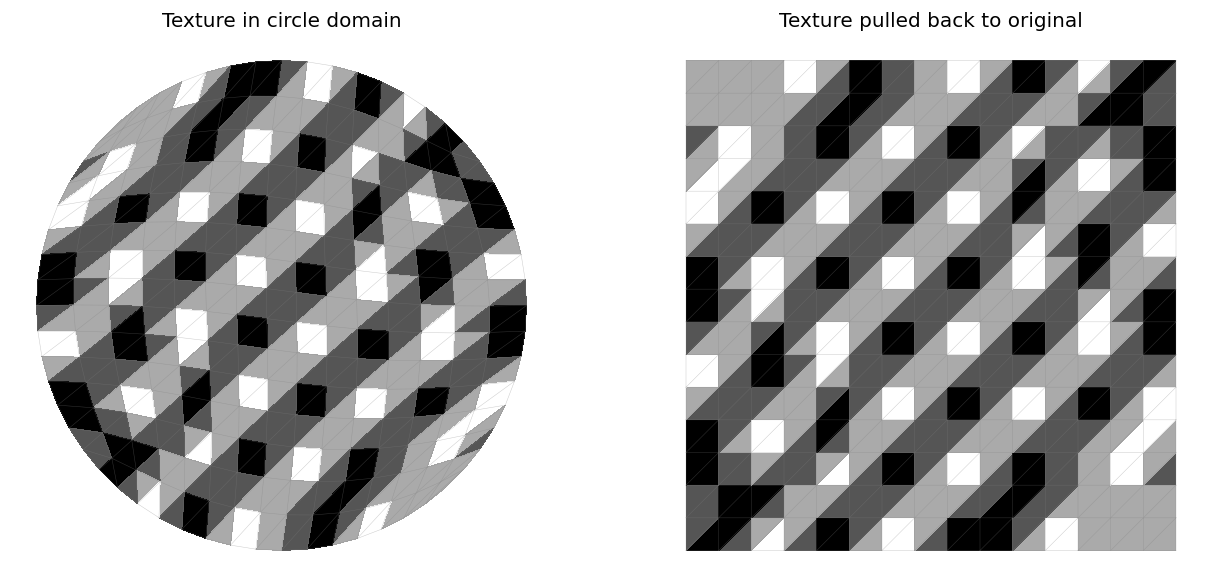

In [4]:
# Transfer a checkerboard texture from circle to original
def checkerboard(xy, k=4):
    return (np.floor(k * xy[:,0]) + np.floor(k * xy[:,1])) % 2

texture = checkerboard(u_circle)
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Texture in parameterised domain
tri_obj = Triangulation(u_circle[:,0], u_circle[:,1], tris)
axes[0].tripcolor(tri_obj, texture, cmap='gray', shading='flat')
axes[0].triplot(u_circle[:,0], u_circle[:,1], tris, color='gray', linestyle='-', lw=0.3, alpha=0.4)
axes[0].set_aspect('equal'); axes[0].axis('off'); axes[0].set_title('Texture in circle domain')

# Pull back to original domain
tri_orig = Triangulation(pts[:,0], pts[:,1], tris)
axes[1].tripcolor(tri_orig, texture, cmap='gray', shading='flat')
axes[1].triplot(pts[:,0], pts[:,1], tris, color='gray', linestyle='-', lw=0.3, alpha=0.4)
axes[1].set_aspect('equal'); axes[1].axis('off'); axes[1].set_title('Texture pulled back to original')

plt.tight_layout(); plt.show()

## Interactive: mesh resolution

In [5]:
def show_param(m_param=10):
    pts_i, tris_i, bnd_i = make_square_mesh(m_param)
    L_i = build_uniform_laplacian(pts_i, tris_i, bnd_i)
    N_i = len(pts_i)
    bnd_idx_i = np.where(bnd_i)[0]
    bnd_pts_i = pts_i[bnd_idx_i]
    center_i = bnd_pts_i.mean(axis=0)
    angles_i = np.arctan2(bnd_pts_i[:,1]-center_i[1], bnd_pts_i[:,0]-center_i[0])
    order_i = np.argsort(angles_i)
    bnd_sorted_i = bnd_idx_i[order_i]
    nb = len(bnd_idx_i)
    circ_i = np.column_stack([np.cos(np.linspace(0, 2*np.pi, nb, endpoint=False)),
                               np.sin(np.linspace(0, 2*np.pi, nb, endpoint=False))])
    target_i = np.zeros((N_i, 2))
    target_i[bnd_sorted_i] = circ_i
    u_i = harmonic_param(pts_i, L_i, bnd_i, target_i)
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    axes[0].triplot(pts_i[:,0], pts_i[:,1], tris_i, 'k-', lw=0.5)
    axes[0].set_aspect('equal'); axes[0].axis('off'); axes[0].set_title(f'Original ($m={m_param}$)')
    axes[1].triplot(u_i[:,0], u_i[:,1], tris_i, 'k-', lw=0.5)
    axes[1].scatter(u_i[bnd_i,0], u_i[bnd_i,1], s=20, c='tomato', zorder=5)
    axes[1].set_aspect('equal'); axes[1].axis('off'); axes[1].set_title('Harmonic parameterisation')
    plt.tight_layout(); plt.show()

interact(show_param,
         m_param=IntSlider(value=10, min=5, max=20, step=1, description='$m$'));

interactive(children=(IntSlider(value=10, description='$m$', max=20, min=5), Output()), _dom_classes=('widget-…

## Bibliographical resources

- Tutte, W. T. (1963). How to draw a graph. *Proceedings of the London Mathematical Society*, 13(1), 743–768.
- Floater, M. S. (1997). Parametrization and smooth approximation of surface triangulations. *Computer Aided Geometric Design*, 14(3), 231–250.
- Joshi, P., Meyer, M., DeRose, T., Green, B. and Sanocki, T. (2007). Harmonic coordinates for character articulation. *ACM Transactions on Graphics*, 26(3), Article 71.
- Lévy, B., Petitjean, S., Ray, N. and Maillot, J. (2002). Least squares conformal maps for automatic texture atlas generation. *ACM SIGGRAPH*, 362–371.
- Desbrun, M., Meyer, M. and Alliez, P. (2002). Intrinsic parameterizations of surface meshes. *Computer Graphics Forum*, 21(3), 209–218.